In [268]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [269]:
df = pd.read_csv(r"E:\hackthon\Future of Jobs AI Dataset.csv")

In [270]:
df

,job_title,country,experience_level,education_level,year,salary,ai_risk_score,primary_skill,skill_demand_score,job_openings,job_survival_class,salary_bucket,ai_risk_category
0,Data Scientist,USA,Senior,Master,2022,61931.03,0.32,Python,88,39158,2,High,Medium Risk
1,Software Engineer,India,Senior,Bachelor,2032,21330.84,0.52,Java,80,7265,1,High,Medium Risk
2,Data Scientist,Canada,Mid,Bachelor,2015,24211.17,0.25,Python,70,22962,1,High,Low Risk
3,Data Scientist,India,Entry,PhD,2034,11794.86,0.44,Python,95,17023,1,Medium,Medium Risk
4,Data Analyst,Canada,Entry,PhD,2035,17999.26,0.75,SQL,61,3433,0,Medium,High Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12338,Data Scientist,Germany,Entry,Master,2030,27079.49,0.40,Python,89,2395,1,High,Medium Risk
12339,Cybersecurity Analyst,USA,Mid,Bachelor,2028,42474.50,0.28,Security,73,24254,2,High,Low Risk
12340,Software Engineer,India,Senior,Master,2028,19381.43,0.48,Java,77,27356,1,Medium,Medium Risk
12341,AI Researcher,Australia,Entry,PhD,2023,32647.87,0.13,Deep Learning,78,48428,2,High,Low Risk


## INFO

`salary_bucket`=These features help the model predict job security by evaluating how a person's skills, education, and salary align with AI automation trends.

`job_title` =This feature determines if a specific role is creative and complex enough to survive AI automation or simple enough to be replaced by it.

`country`=This feature identifies if a job is in a country with high AI adoption, which directly impacts how fast automation replaces or assists workers.


`experience Level`: Indicates how much professional practice a person has, which affects their ability to handle complex tasks AI can't do.

`Education Level`: Represents the formal qualification and foundational knowledge that determines a person's technical depth and job eligibility.

`Year`: Tracks how job roles and AI risks change over time.

`Salary`: Shows the financial value of a role and its cost-effectiveness for automation.

`AI Risk Score`: A numerical value predicting the likelihood of a job being replaced by AI.

`Primary Skill`: The core expertise that determines if a human is still needed for the job.

`Skill Demand Score`: Measures how much the market currently needs a specific talent.

`Job Openings`: Indicates the availability and growth of a particular career path.

`Job Survival Class`: Categorizes how well a role can withstand the AI revolution.

`Salary Bucket`: Groups income levels to see which pay scales are most at risk.

`AI Risk Category`: Labels the danger level (Low, Medium, High) for a specific job profile

In [271]:
df.shape

(12343, 13)

In [272]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12343 entries, 0 to 12342
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   job_title           12343 non-null  object 
 1   country             12343 non-null  object 
 2   experience_level    12343 non-null  object 
 3   education_level     12343 non-null  object 
 4   year                12343 non-null  int64  
 5   salary              12343 non-null  float64
 6   ai_risk_score       12343 non-null  float64
 7   primary_skill       12343 non-null  object 
 8   skill_demand_score  12343 non-null  int64  
 9   job_openings        12343 non-null  int64  
 10  job_survival_class  12343 non-null  int64  
 11  salary_bucket       12343 non-null  object 
 12  ai_risk_category    12343 non-null  object 
dtypes: float64(2), int64(4), object(7)
memory usage: 1.2+ MB


In [273]:
df.describe()

,year,salary,ai_risk_score,skill_demand_score,job_openings,job_survival_class
count,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000
mean,2025.054525,34553.729166,0.396008,79.453374,25223.652029,1.310054
std,6.058714,18024.702961,0.187665,11.483535,14163.309081,0.658417
min,2015.000000,3875.170000,0.050000,60.000000,1002.000000,0.000000
25%,2020.000000,21331.405000,0.260000,70.000000,12993.000000,1.000000
50%,2025.000000,31573.380000,0.360000,79.000000,24896.000000,1.000000
75%,2030.000000,45307.845000,0.490000,89.000000,37440.500000,2.000000
max,2035.000000,113589.260000,0.850000,99.000000,49998.000000,2.000000


In [274]:
df.isna().sum()

job_title             0
country               0
experience_level      0
education_level       0
year                  0
salary                0
ai_risk_score         0
primary_skill         0
skill_demand_score    0
job_openings          0
job_survival_class    0
salary_bucket         0
ai_risk_category      0
dtype: int64

In [275]:
df.duplicated().sum()

np.int64(0)

##### We converted the ai_risk_category column into numerical values using mapping (Low Risk = 0, Medium Risk = 1, High Risk = 2) because machine learning models cannot understand text labels directly. This dataset has three classes, so mapping helps the model treat it as a multi-class classification problem and learn patterns effectively.

In [276]:
df['ai_risk_category'] = df['ai_risk_category'].map({
    'Low Risk': 0,
    'Medium Risk': 1,
    'High Risk':2
    
})

## Categorical vs Numerical Feature Selection

In [277]:
nos_col = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_col = df.select_dtypes(include=['object']).columns.tolist()

In [278]:
nos_col

['year',
 'salary',
 'ai_risk_score',
 'skill_demand_score',
 'job_openings',
 'job_survival_class',
 'ai_risk_category']

In [279]:
cat_col

['job_title',
 'country',
 'experience_level',
 'education_level',
 'primary_skill',
 'salary_bucket']

## Numerical Univariate analysis¶

In [280]:
def num_univariate_analysis(df, col):
    
    plt.figure(figsize=(15,10))
    
    # 1. Histogram
    plt.subplot(2,2,1)
    df[col].hist(bins=30)
    plt.title(f'Histogram of {col}')
    
    # 2. Boxplot
    plt.subplot(2,2,2)
    df.boxplot(column=col)
    plt.title(f'Boxplot of {col}')    

    
    # 3. KDE Plot
    plt.subplot(2,2,3)
    df[col].plot(kind='kde')
    plt.title(f'KDE Plot of {col}')
    
    # 4. Violin Plot
    plt.subplot(2,2,4)
    sns.violinplot(x=df[col])
    plt.title(f'Violin Plot of {col}')
    
    plt.tight_layout()
    plt.show()

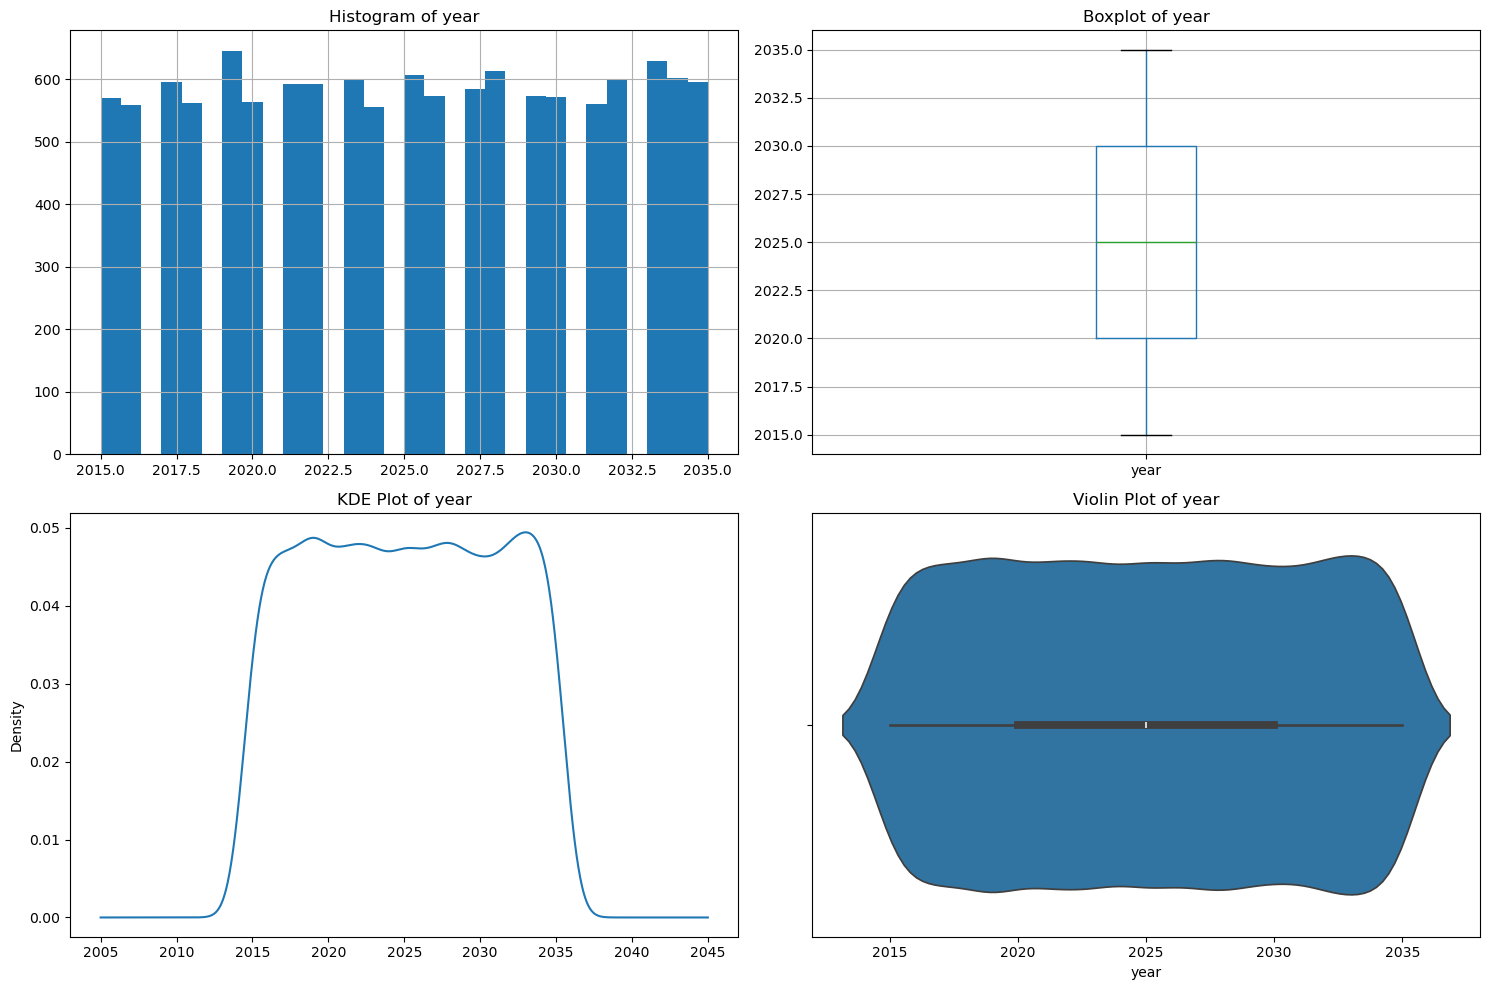

In [281]:
num_univariate_analysis(df,'year')

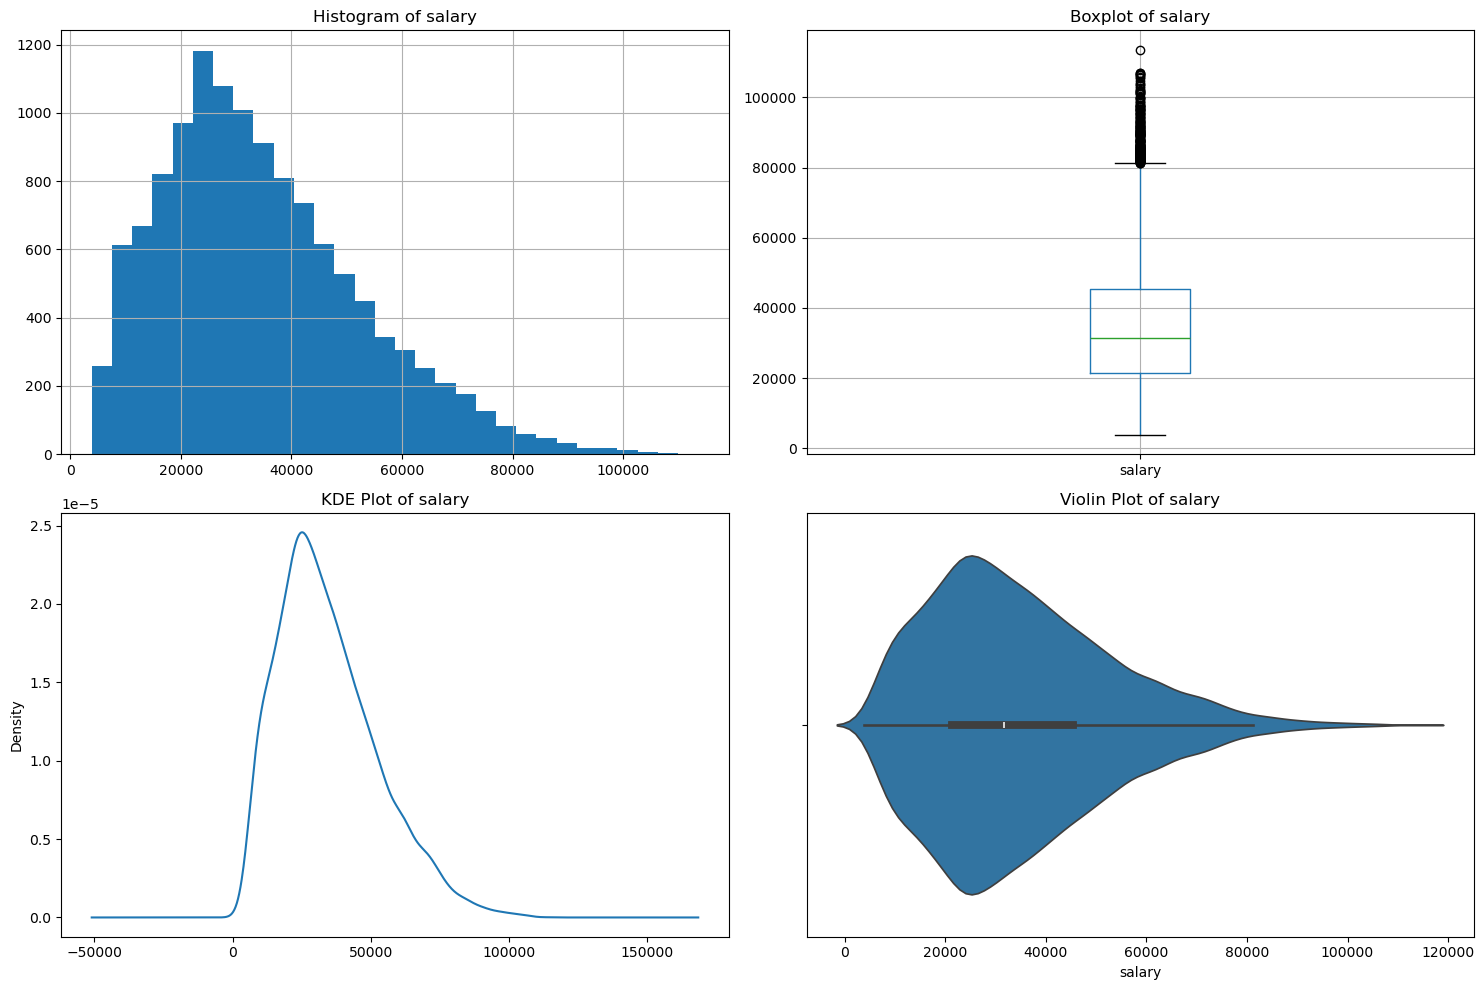

In [282]:
num_univariate_analysis(df,'salary')

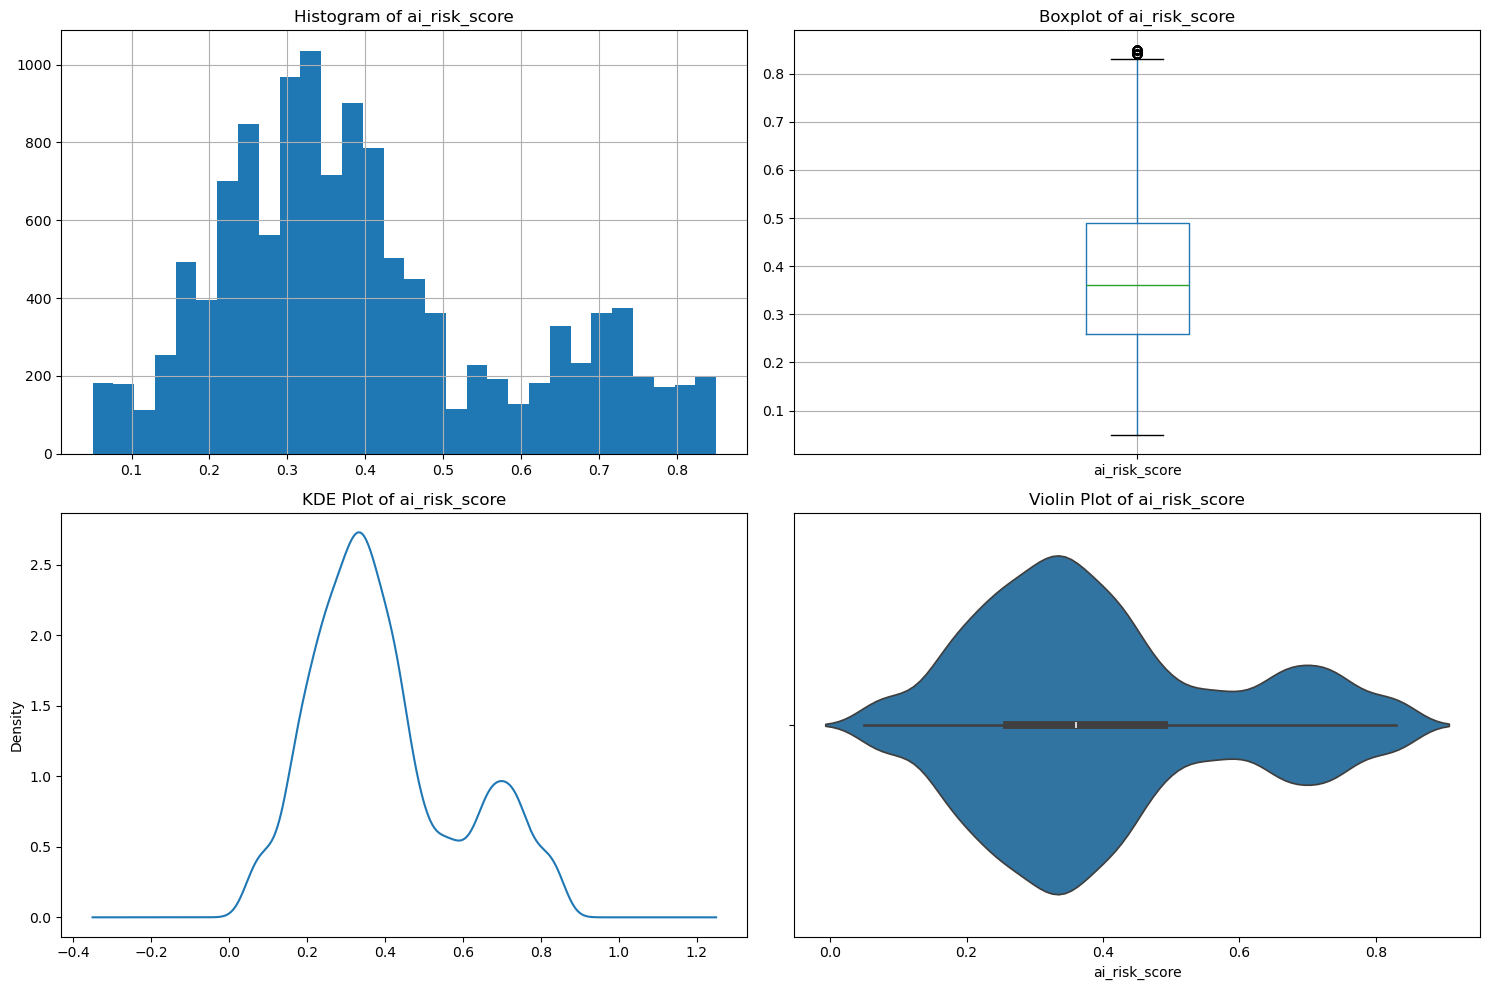

In [283]:
num_univariate_analysis(df,'ai_risk_score')

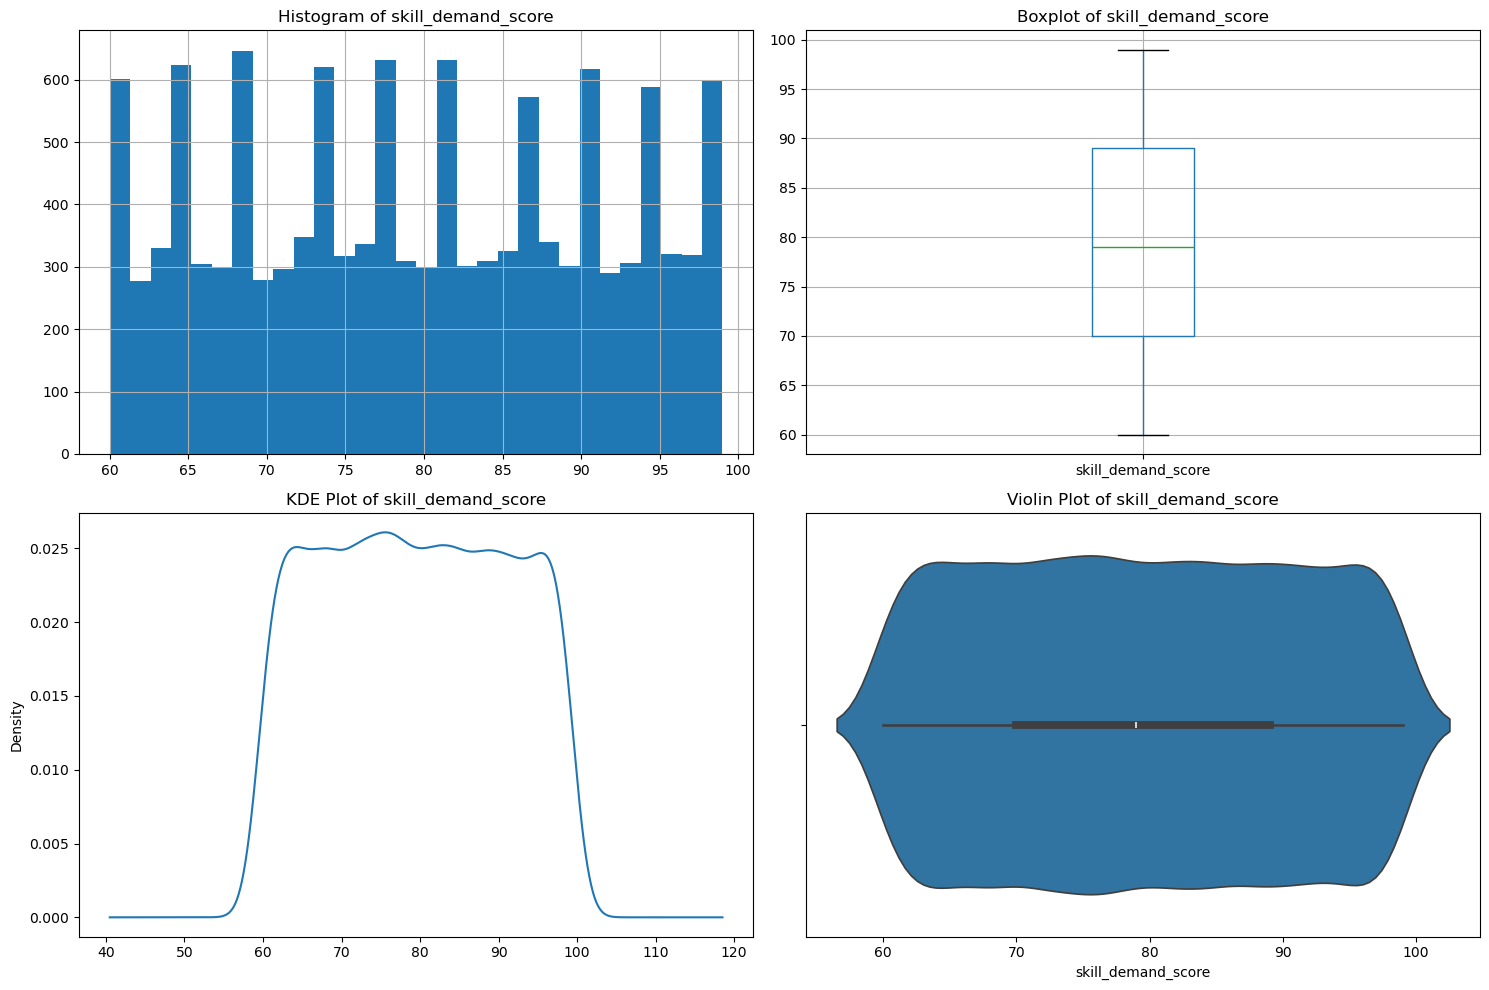

In [284]:
num_univariate_analysis(df,'skill_demand_score')

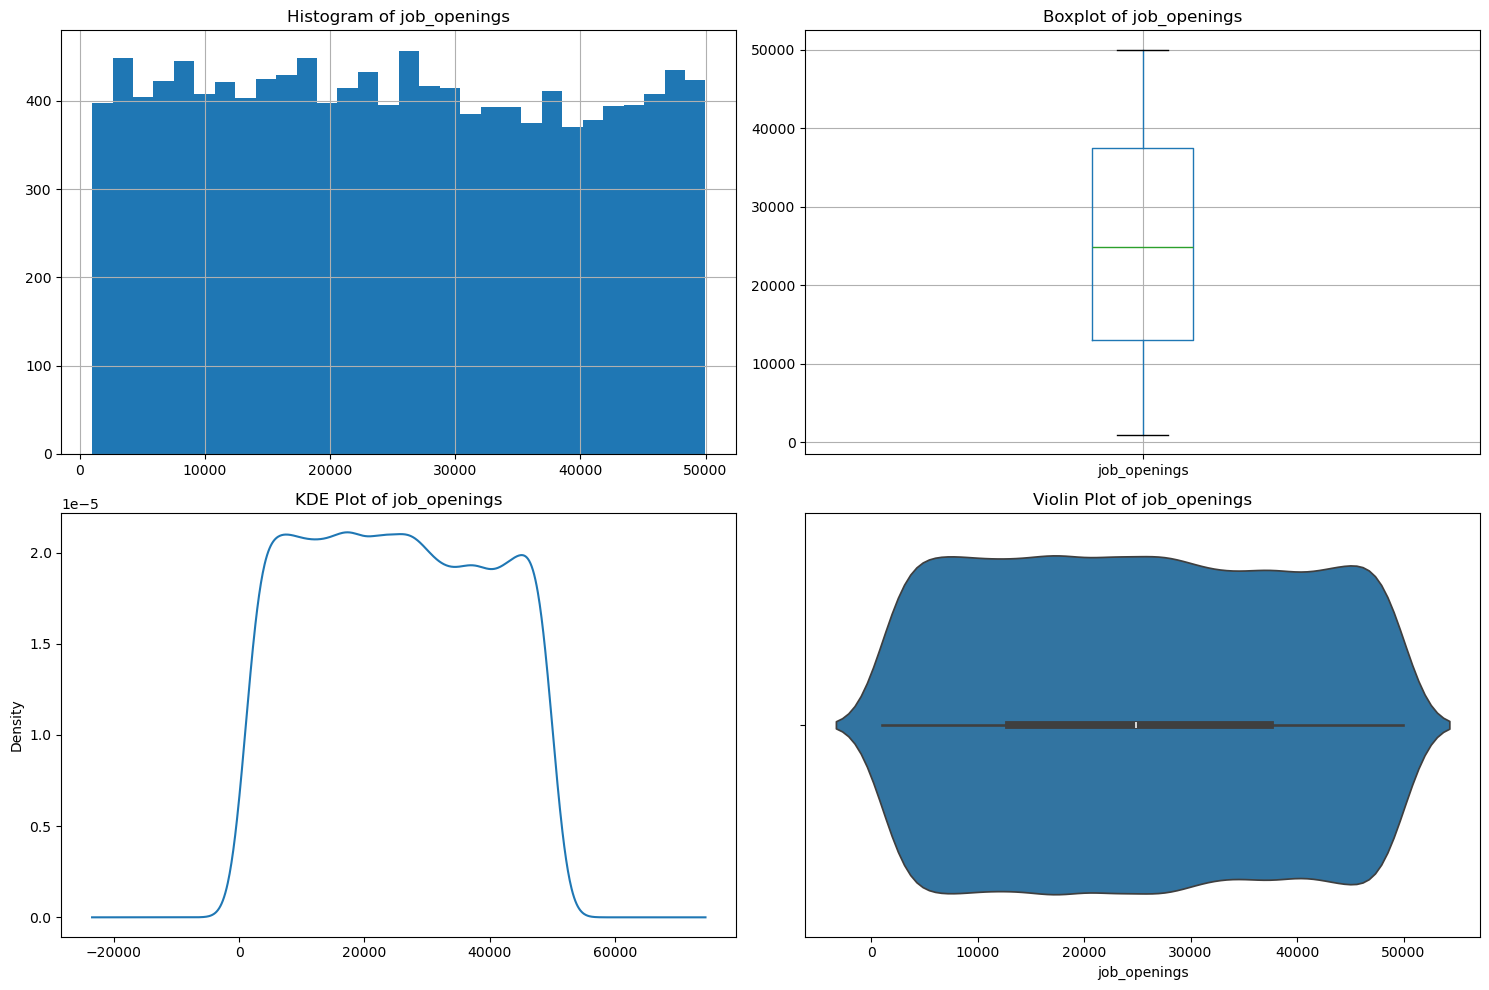

In [285]:
num_univariate_analysis(df,'job_openings')

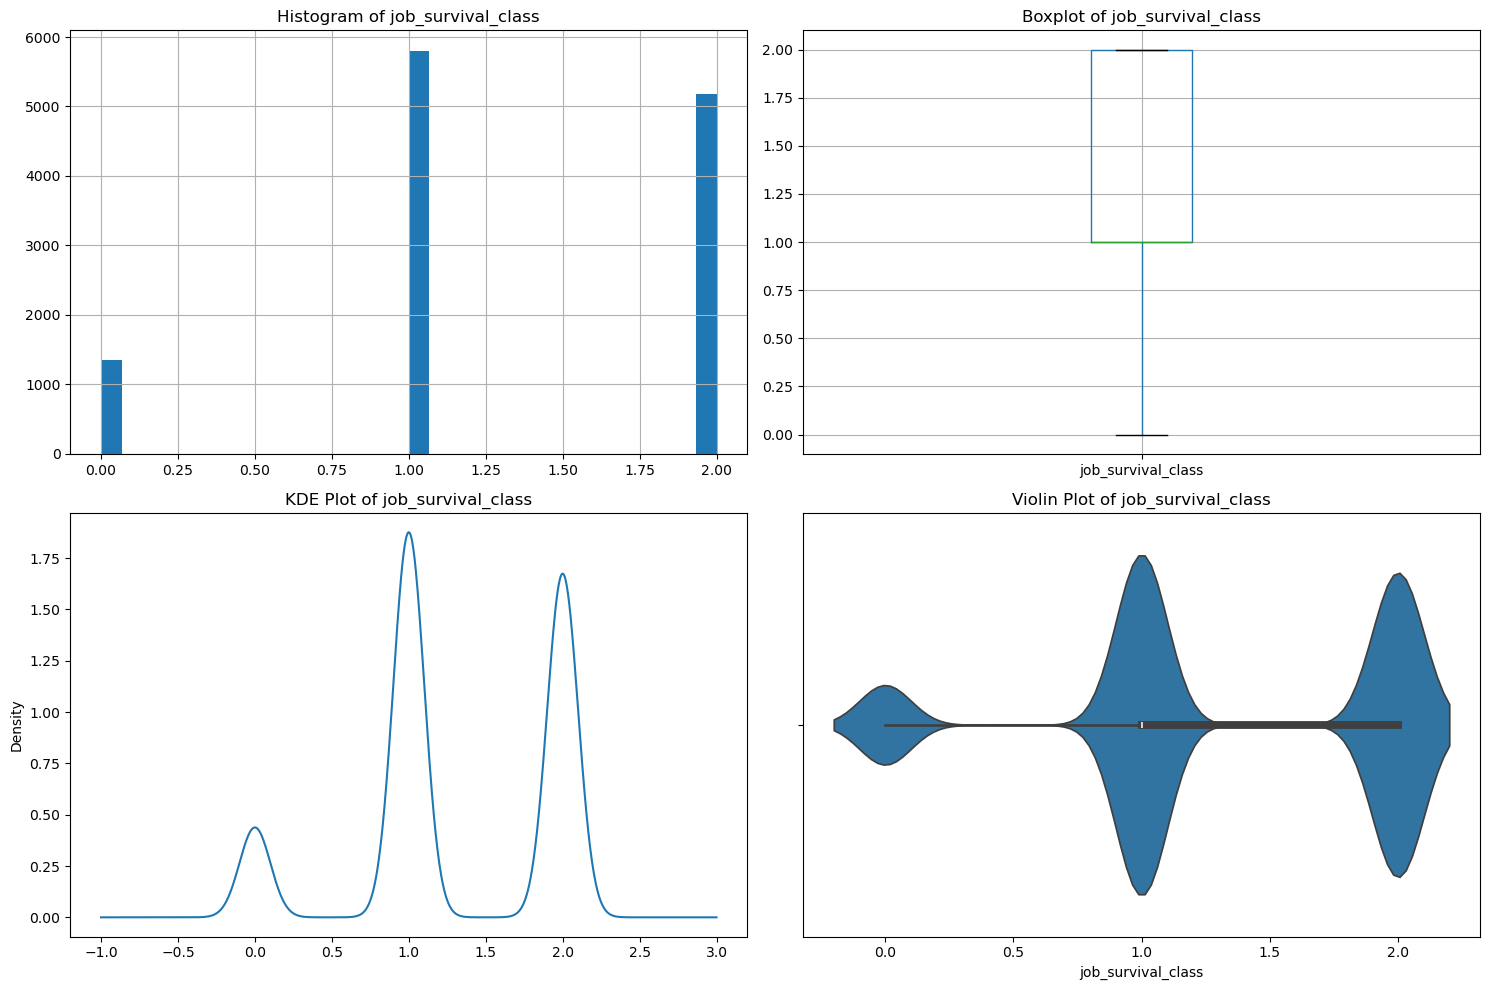

In [286]:
num_univariate_analysis(df,'job_survival_class')

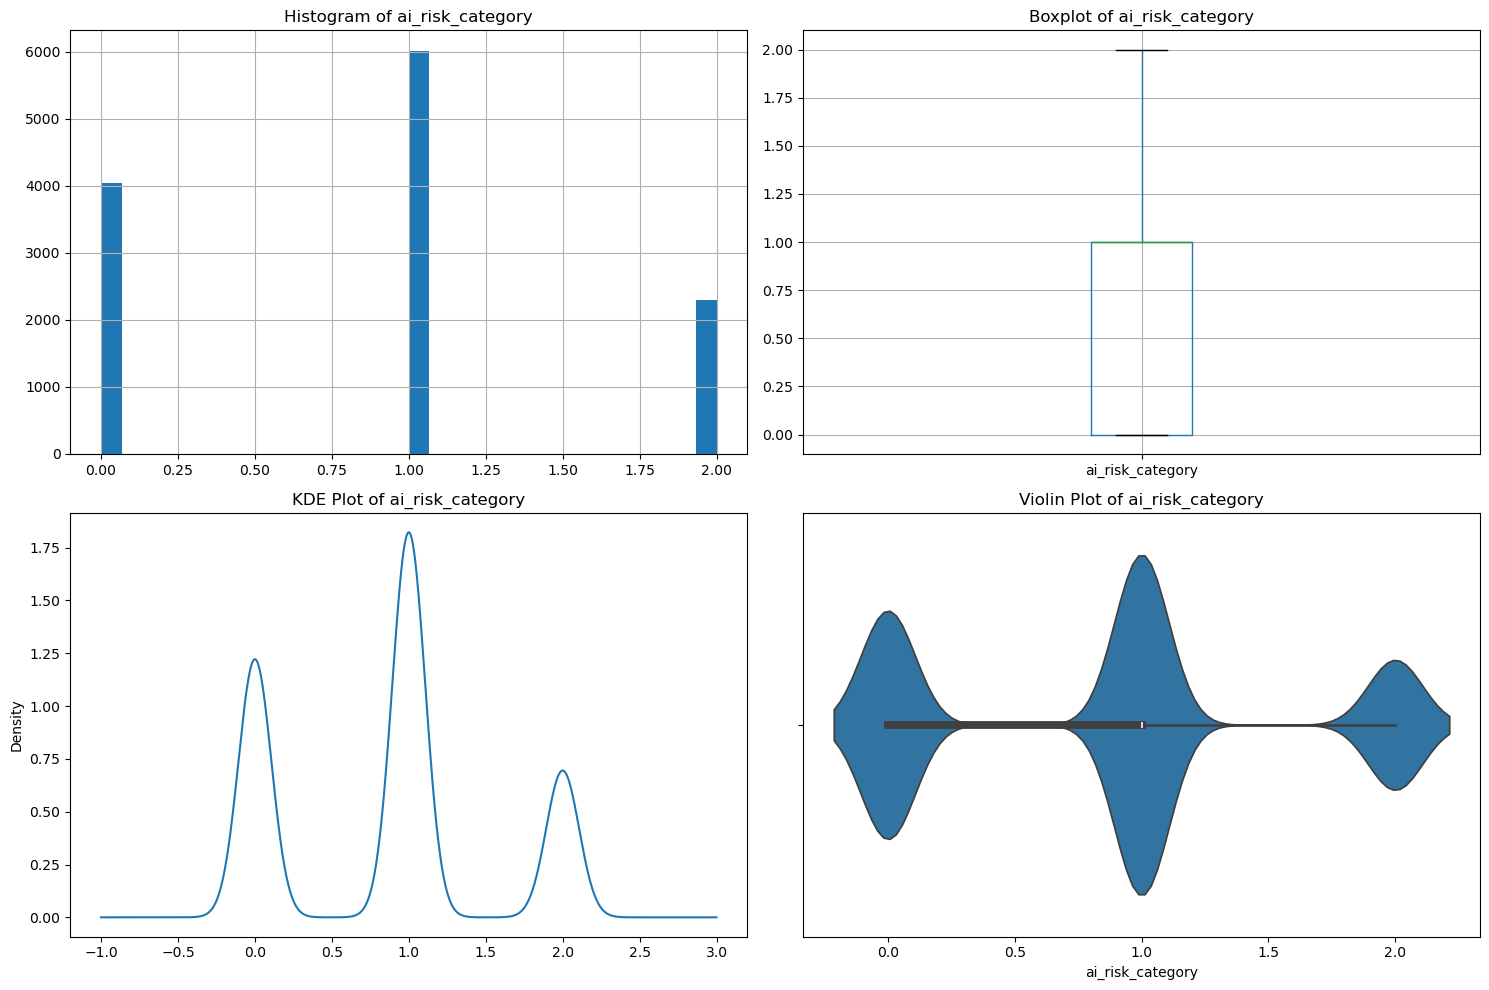

In [287]:

num_univariate_analysis(df,'ai_risk_category')

## Categorical Univariate Analysis

In [288]:
def cat_univariate_analysis(df, col):
    
    plt.figure(figsize=(10,7))
    
    # 1. Count Plot
    plt.subplot(2,2,1)
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    

    # 2. Pie Chart
    plt.subplot(2,2,2)
    df[col].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.ylabel('')
    plt.title(f'Pie Chart of {col}')
    
    # 3. Top Categories (clean view)
    plt.subplot(2,2,3)
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'Top Categories of {col}')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

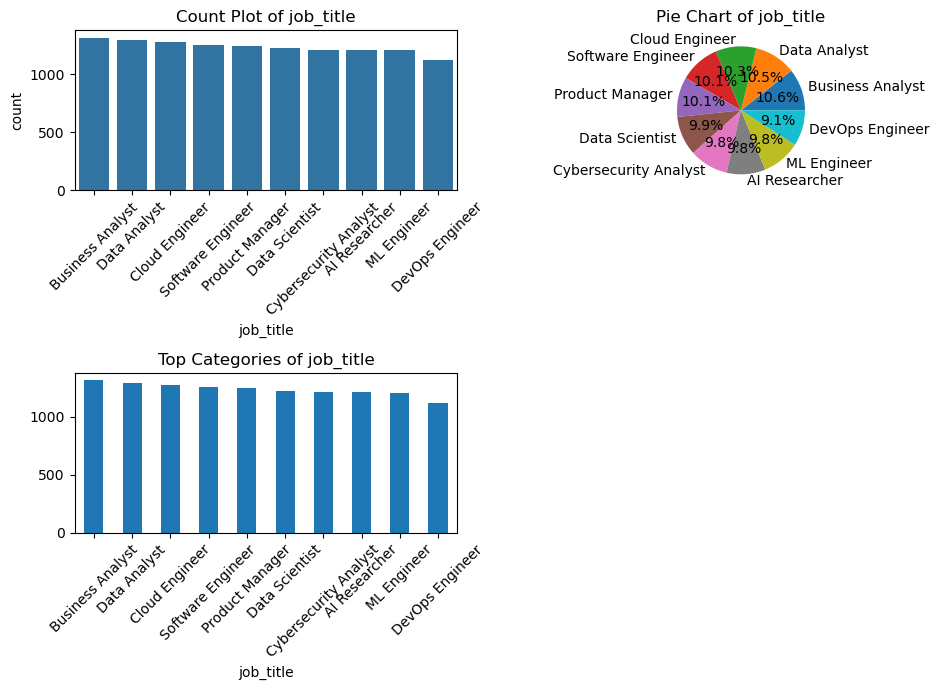

In [289]:
cat_univariate_analysis(df,'job_title')

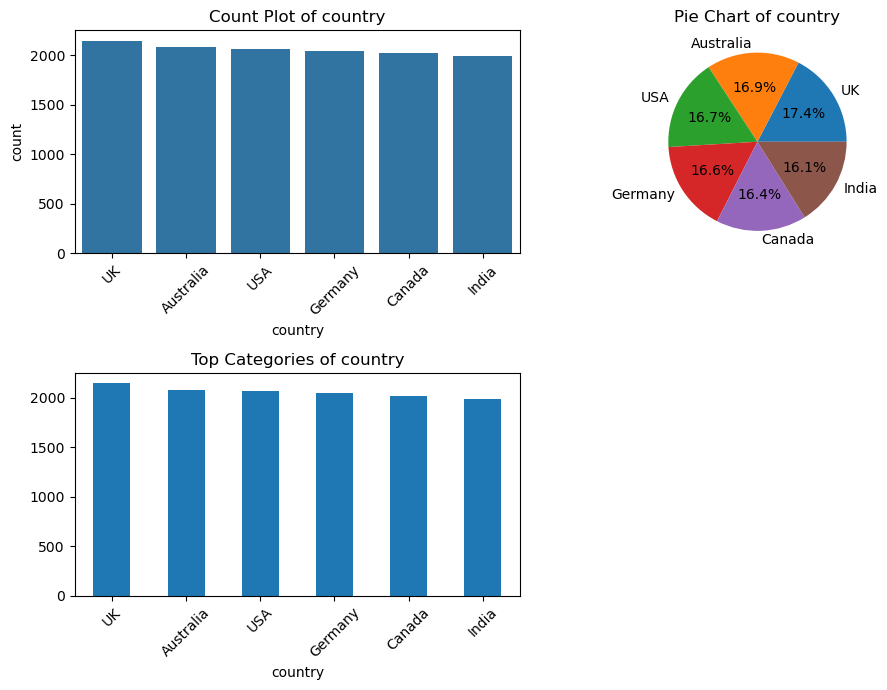

In [290]:
cat_univariate_analysis(df,'country')

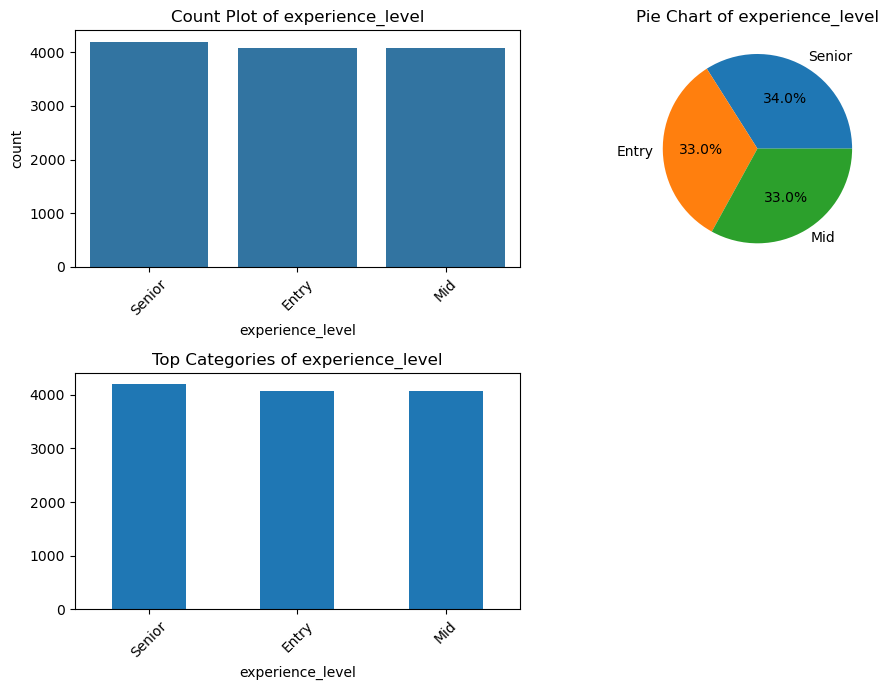

In [291]:
cat_univariate_analysis(df,'experience_level')

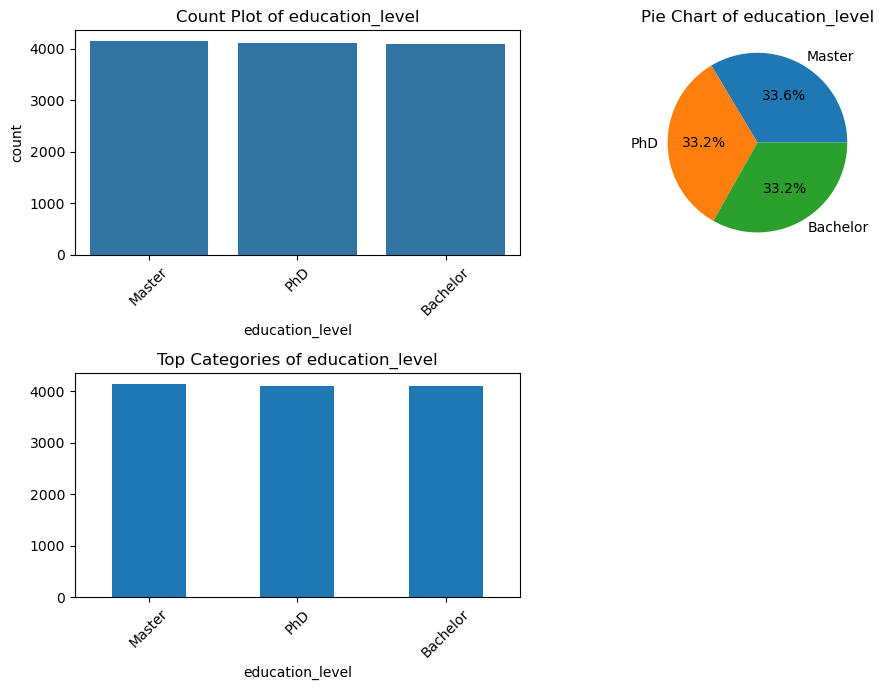

In [292]:
cat_univariate_analysis(df,'education_level')

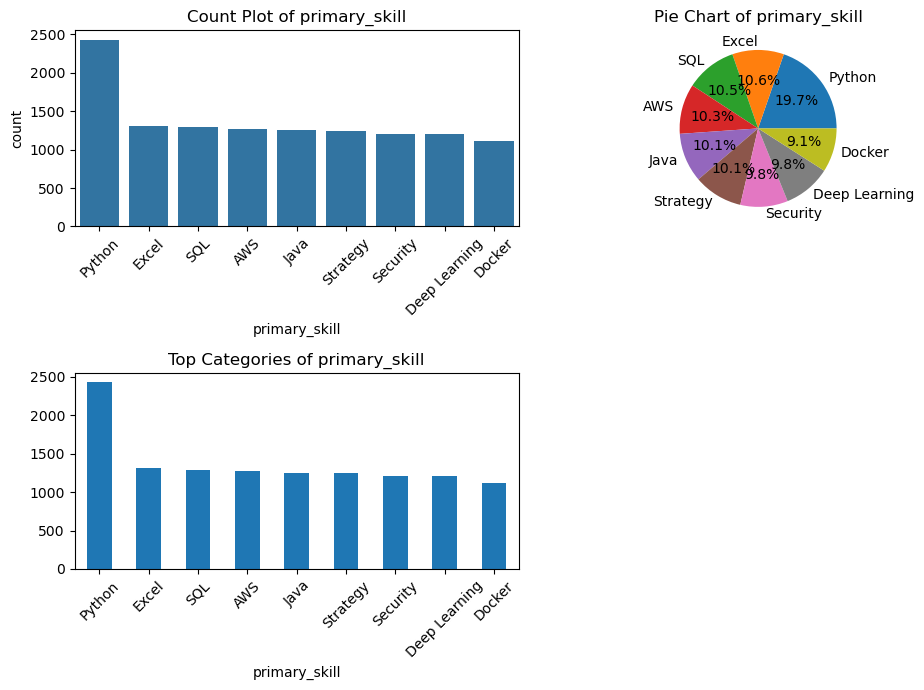

In [293]:
cat_univariate_analysis(df,'primary_skill')

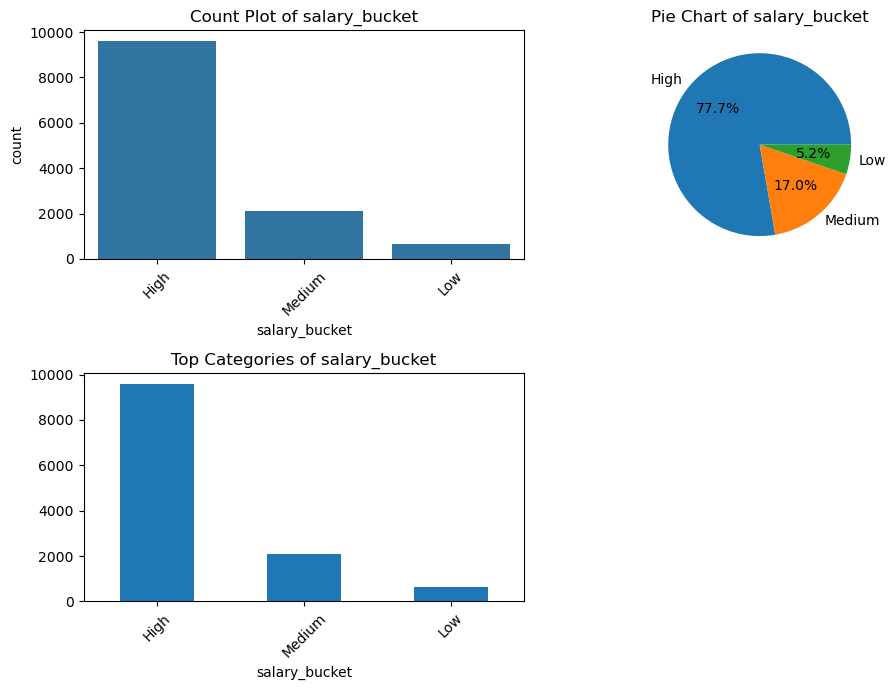

In [294]:
cat_univariate_analysis(df,'salary_bucket')

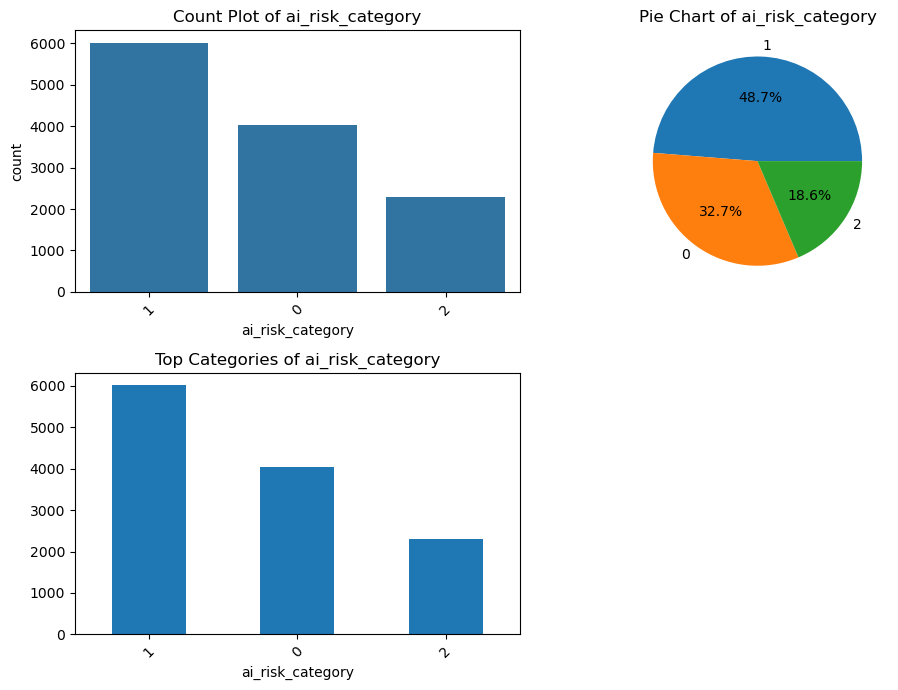

In [295]:
cat_univariate_analysis(df,'ai_risk_category')

In [296]:
cat_col

['job_title',
 'country',
 'experience_level',
 'education_level',
 'primary_skill',
 'salary_bucket']

## Numerical vs Target Bivariate Analysis

In [297]:
corr = df.corr(numeric_only=True)
print(corr['ai_risk_category'].sort_values(ascending=False))

ai_risk_category      1.000000
ai_risk_score         0.914453
year                  0.283504
job_openings          0.015726
skill_demand_score    0.009894
salary               -0.218045
job_survival_class   -0.607208
Name: ai_risk_category, dtype: float64


In [298]:
def num_vs_target_analysis(df, num_col, target_col):
    
    plt.figure(figsize=(15,10))
    
    # 1. Box Plot
    plt.subplot(2,2,1)
    sns.boxplot(x=df[target_col], y=df[num_col])
    plt.title(f'{num_col} vs {target_col} (Box Plot)')
    
    # 2. Violin Plot
    plt.subplot(2,2,2)
    sns.violinplot(x=df[target_col], y=df[num_col])
    plt.title(f'{num_col} vs {target_col} (Violin Plot)')
    
    # 3. KDE Plot 
    plt.subplot(2,2,3)
    for val in df[target_col].unique():
        sns.kdeplot(df[df[target_col]==val][num_col], label=f'{target_col}={val}')
    plt.title(f'{num_col} Distribution by {target_col}')
    plt.legend()
    
    # 4. Mean Comparison 
    plt.subplot(2,2,4)
    df.groupby(target_col)[num_col].mean().plot(kind='bar')
    plt.title(f'Mean {num_col} by {target_col}')
    
    plt.tight_layout()
    plt.show()

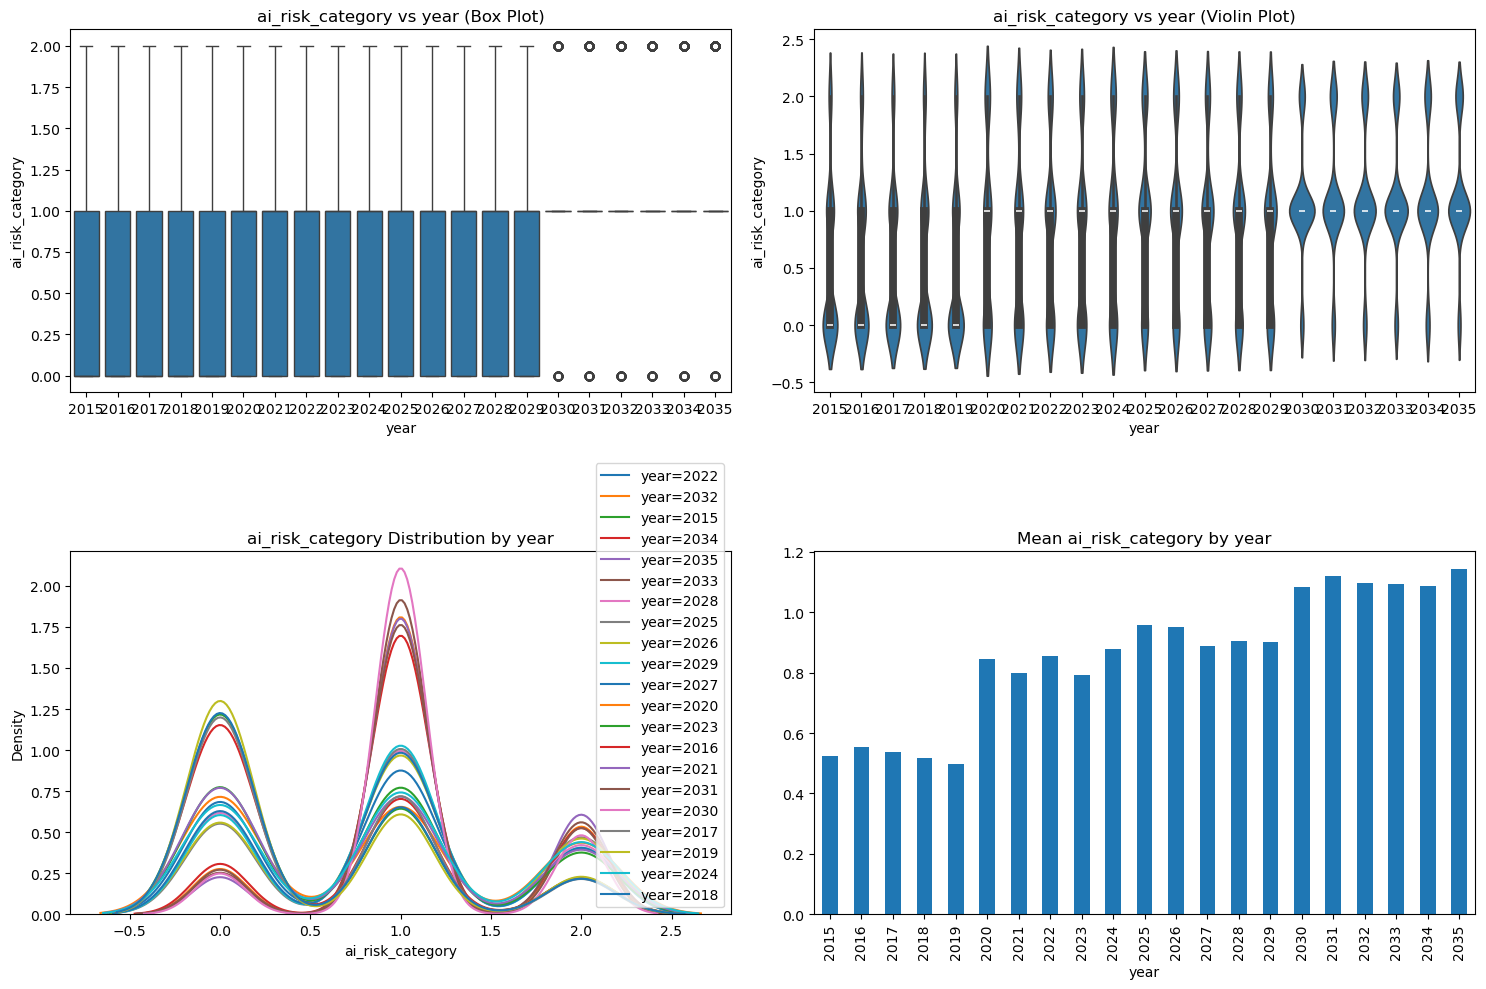

In [299]:
num_vs_target_analysis(df, 'ai_risk_category', 'year')

C:\Users\ganesh gonge\AppData\Local\Temp\ipykernel_5452\368361378.py:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[df[target_col]==val][num_col], label=f'{target_col}={val}')
C:\Users\ganesh gonge\AppData\Local\Temp\ipykernel_5452\368361378.py:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[df[target_col]==val][num_col], label=f'{target_col}={val}')
C:\Users\ganesh gonge\AppData\Local\Temp\ipykernel_5452\368361378.py:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[df[target_col]==val][num_col], label=f'{target_col}={val}')
C:\Users\ganesh gonge\AppData\Local\Temp\ipykernel_5452\368361378.py:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot

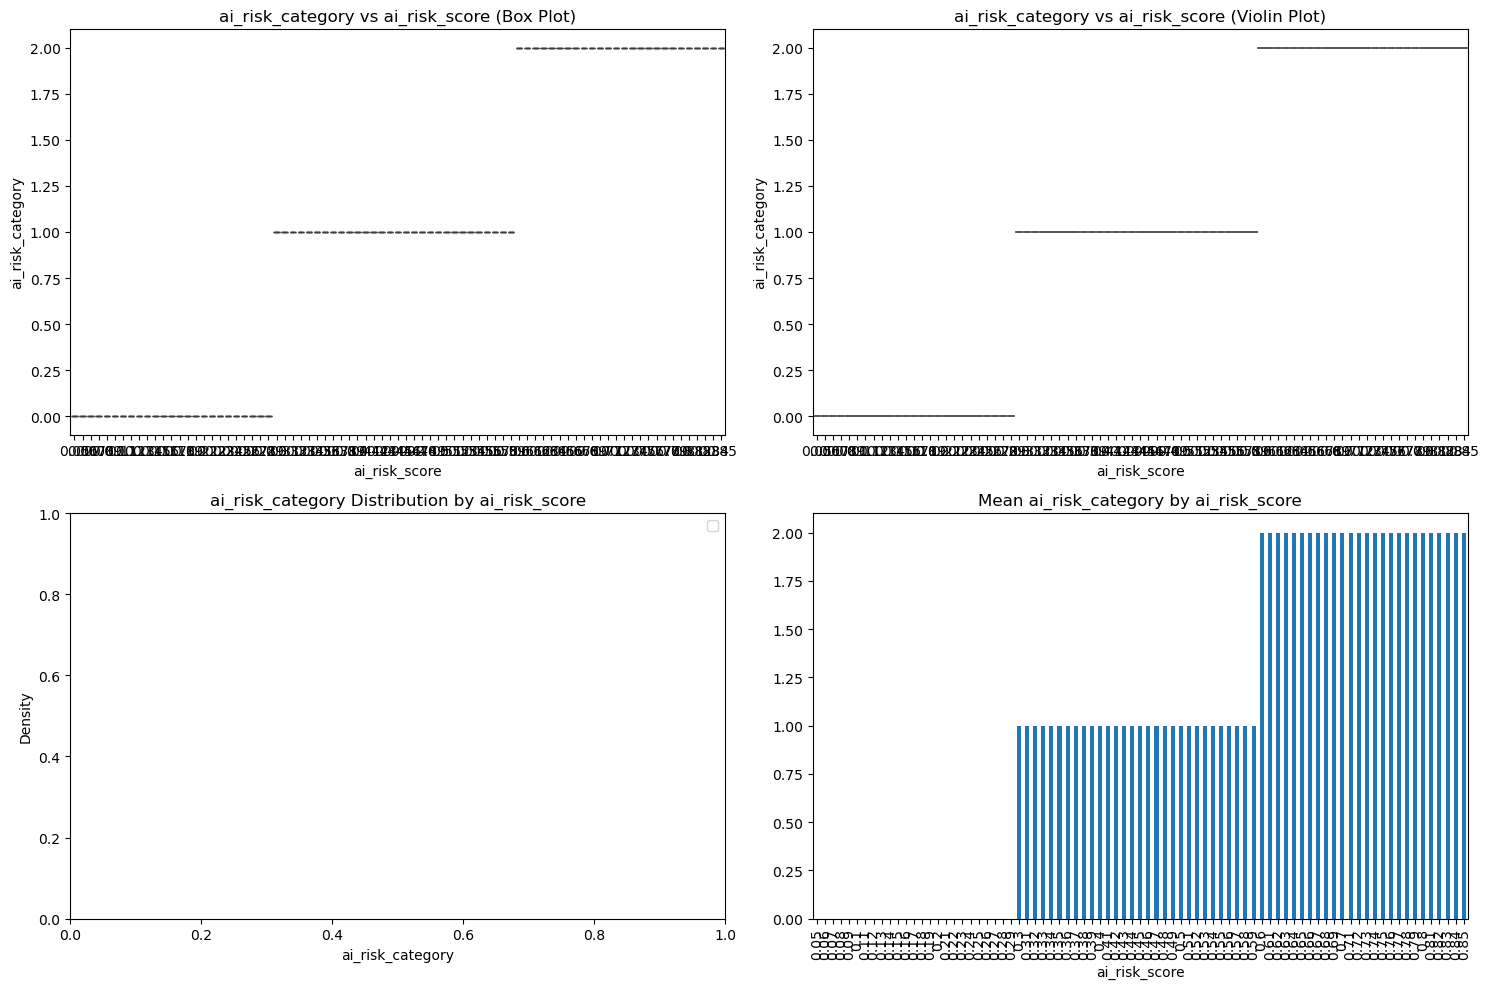

In [300]:
num_vs_target_analysis(df, 'ai_risk_category', 'ai_risk_score')

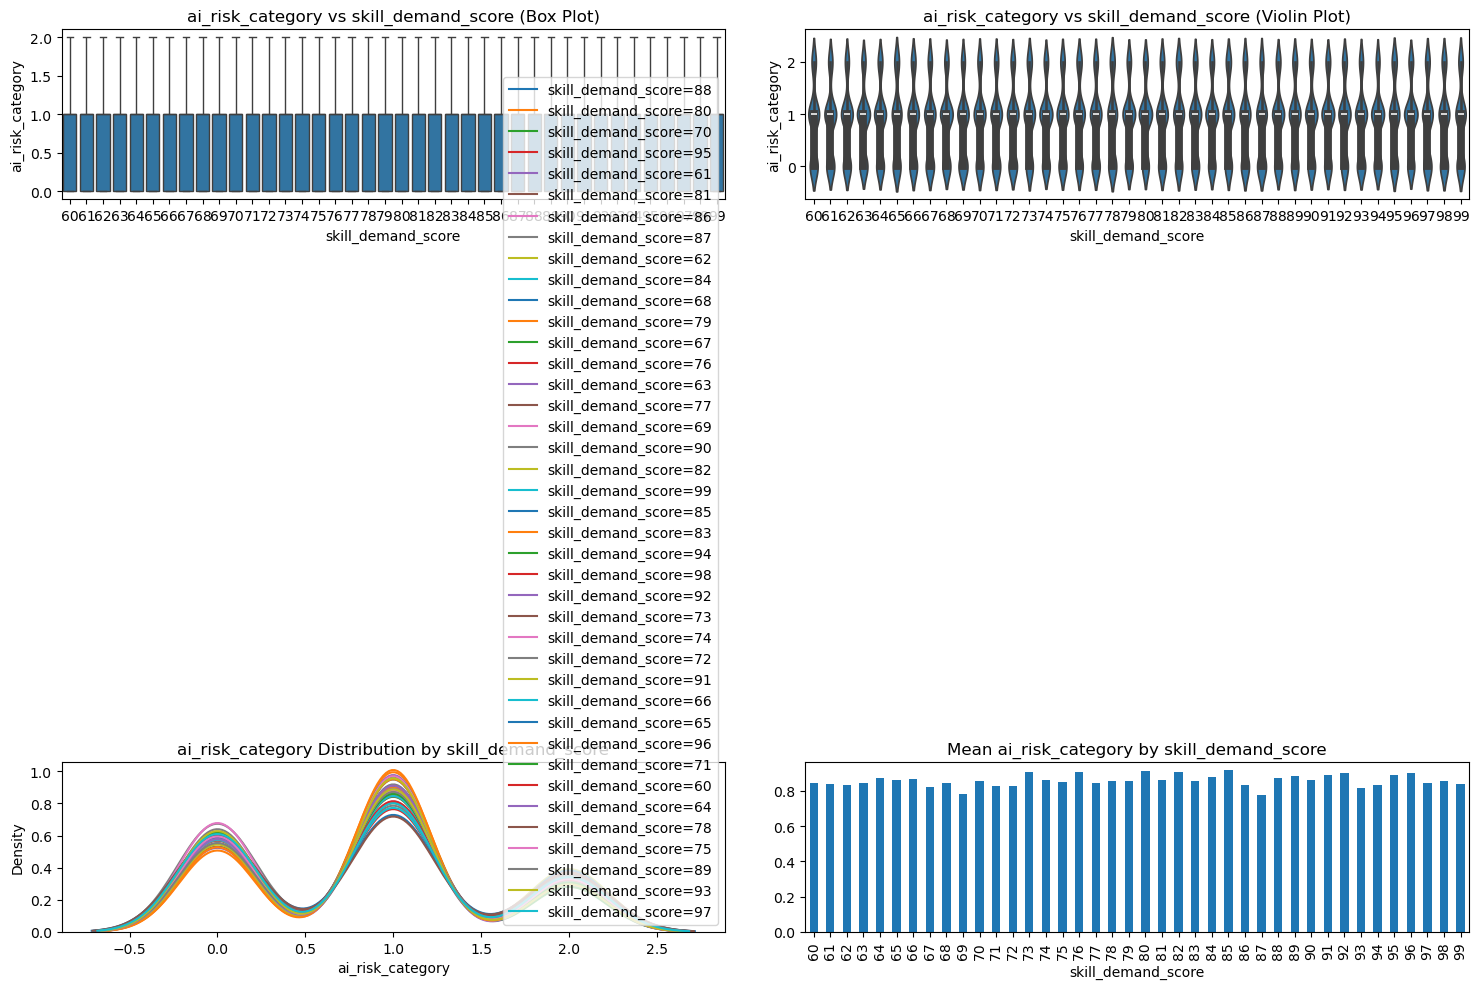

In [301]:
num_vs_target_analysis(df, 'ai_risk_category', 'skill_demand_score')

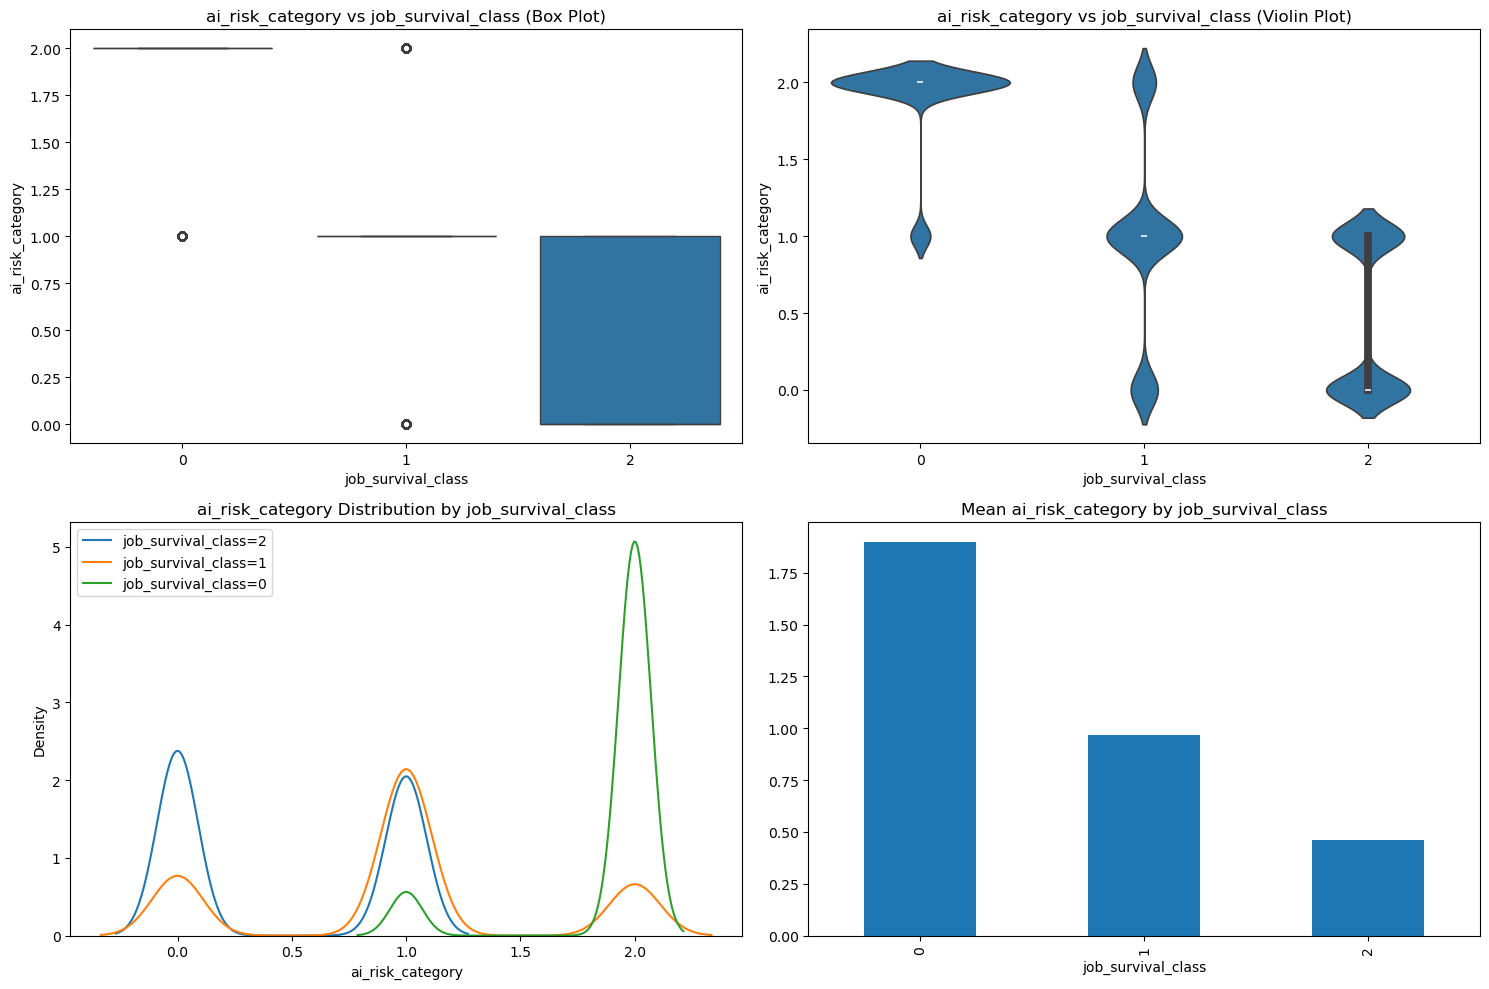

In [302]:
num_vs_target_analysis(df, 'ai_risk_category', 'job_survival_class')

##  Heatmap feature vs feature relation 

<Axes: >

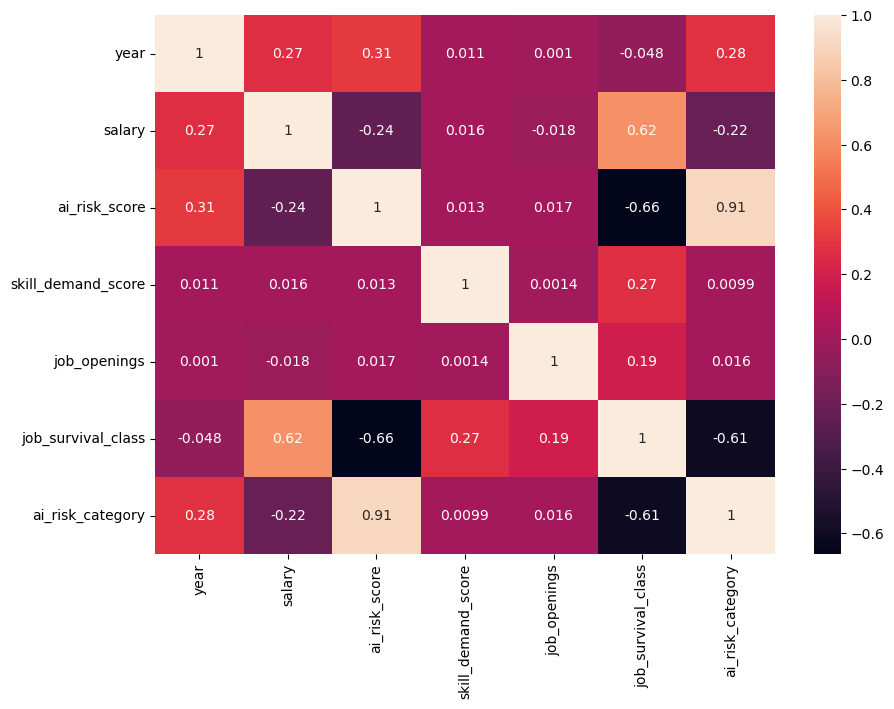

In [303]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True),annot=True)

## Target Column

In [304]:
df['ai_risk_category'].value_counts()

ai_risk_category
1    6016
0    4033
2    2294
Name: count, dtype: int64

<Axes: xlabel='ai_risk_category', ylabel='count'>

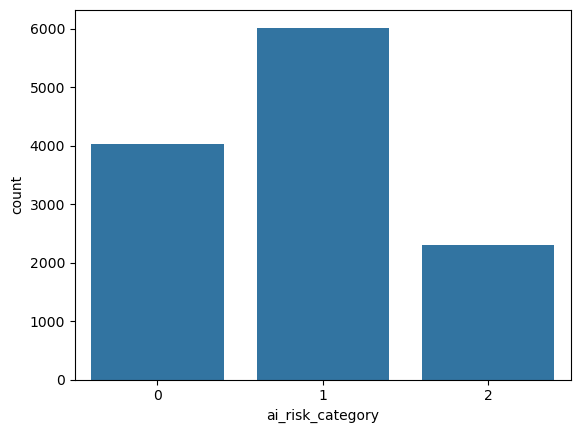

In [305]:
sns.countplot(x='ai_risk_category',data=df)

##### The target col is slightly imbalanced, as the Medium Risk class has more samples compared to Low and High Risk, but the imbalance is not severe.

## Check Outliers box plot nad IQR method

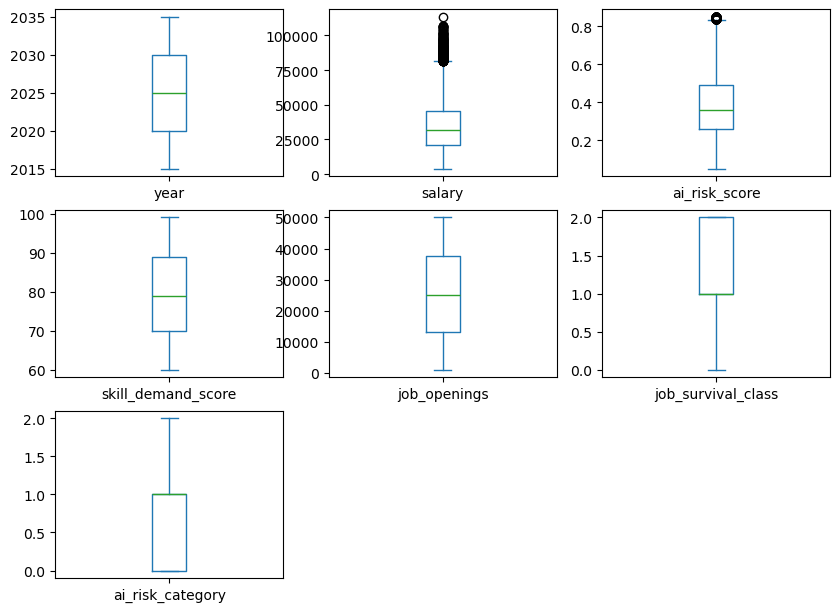

In [306]:
df[nos_col].plot(kind='box',subplots=True,layout=(4,3),figsize=(10,10))
plt.show()

In [307]:
for i in nos_col:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR =Q3 - Q1
    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR
    ot = df[(df[i] < lower) |(df[i]>upper)].shape[0]
    print(i,'=',lower,'=',upper,' =',ot)

year = 2005.0 = 2045.0  = 0
salary = -14633.255000000005 = 81272.505  = 189
ai_risk_score = -0.08499999999999996 = 0.835  = 142
skill_demand_score = 41.5 = 117.5  = 0
job_openings = -23678.25 = 74111.75  = 0
job_survival_class = -0.5 = 3.5  = 0
ai_risk_category = -1.5 = 2.5  = 0


## Check Skewness

In [308]:
df.skew(numeric_only=True)

year                 -0.002089
salary                0.783204
ai_risk_score         0.649878
skill_demand_score    0.011053
job_openings          0.043731
job_survival_class   -0.430881
ai_risk_category      0.202911
dtype: float64

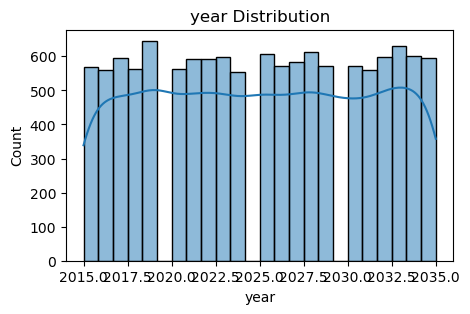

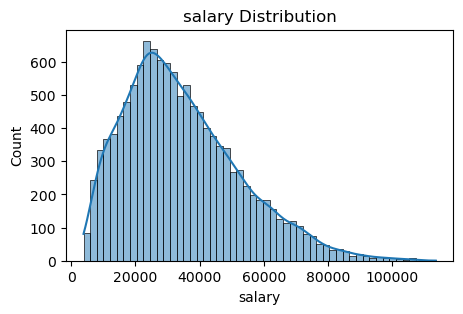

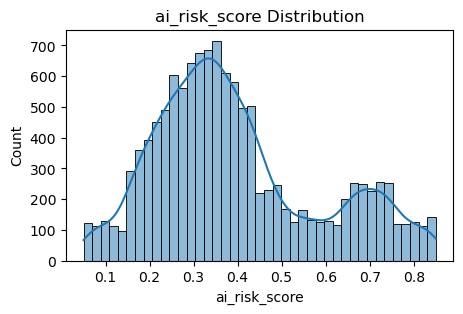

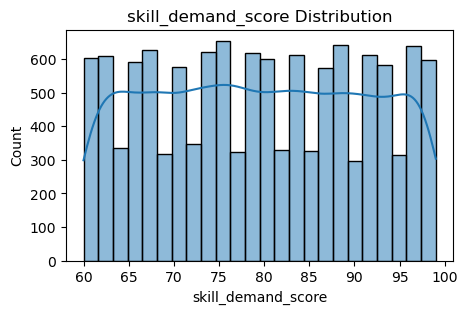

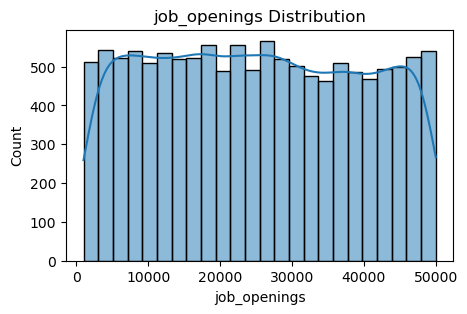

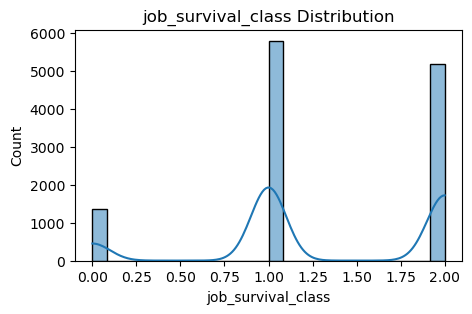

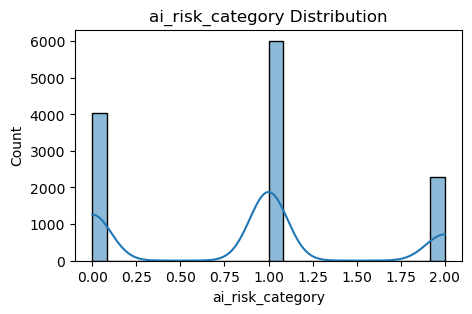

In [309]:
for col in nos_col:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

## Skew
The skewness values show that most features are approximately symmetric, as their values are close to 0. However, the salary column has a high positive skew (0.78), meaning some salaries are much higher than others, which is common in real-world data. This happens because a few individuals earn significantly more compared to the majority.

Since this skewness is natural, handling it is optional. If needed, techniques like log transformation can be applied, but it is not strictly required unless it affects model performance.


## Cat vs tar


In [310]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    if col != 'ai_risk_category':
        ct = pd.crosstab(df[col], df['ai_risk_category'])
        
        chi2, p, _, _ = chi2_contingency(ct)
        
        n = ct.sum().sum()
        phi2 = chi2 / n
        r, k = ct.shape
        cramers_v = np.sqrt(phi2 / min(k-1, r-1))
        
        print(f"{col} → p-value: {p:.5f}, Cramer's V: {cramers_v:.3f}")

job_title → p-value: 0.00000, Cramer's V: 0.822
country → p-value: 0.46250, Cramer's V: 0.020
experience_level → p-value: 0.75038, Cramer's V: 0.009
education_level → p-value: 0.32399, Cramer's V: 0.014
primary_skill → p-value: 0.00000, Cramer's V: 0.805
salary_bucket → p-value: 0.00000, Cramer's V: 0.181


In [311]:
df = df.drop(['country'],axis=1)

## Drop
`"Country` = The `country` column was removed because jobs are not determined by country alone, and including it could add unnecessary noise to the model.


## FEATURE vs FEATURE

<Axes: >

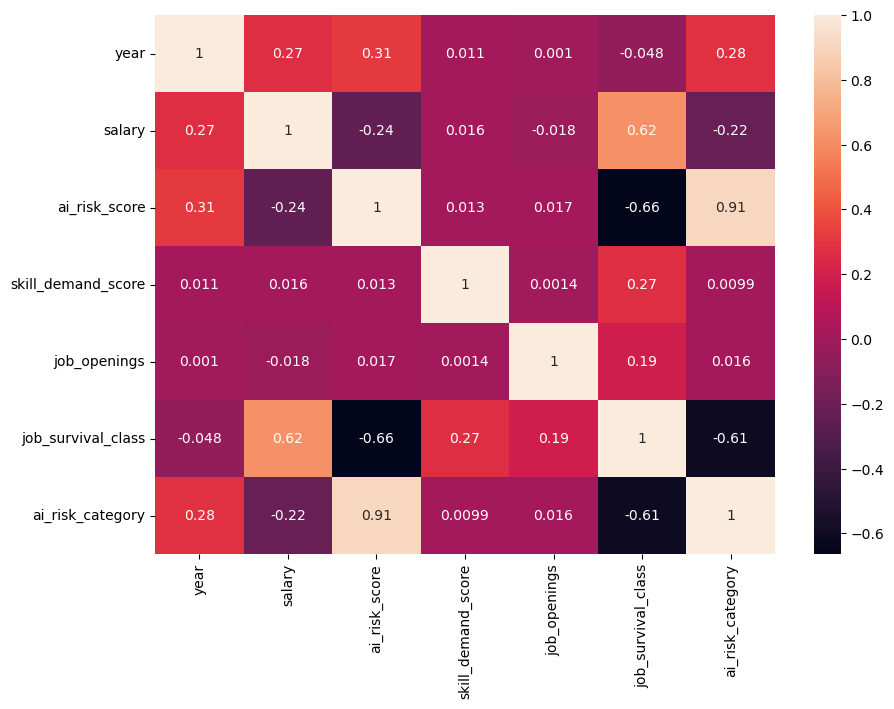

In [312]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [313]:
corr = df.corr(numeric_only=True)
print(corr['ai_risk_category'].sort_values(ascending=False))

ai_risk_category      1.000000
ai_risk_score         0.914453
year                  0.283504
job_openings          0.015726
skill_demand_score    0.009894
salary               -0.218045
job_survival_class   -0.607208
Name: ai_risk_category, dtype: float64


In [314]:
df = df.drop(['salary','year',],axis = 1)

## Drop
``salary`` = The `salary` column was removed because it is not a direct indicator of job automation risk and may introduce bias without improving the model’s predictive performance.

`year`= The `year` column was removed because it does not significantly impact the prediction of job automation risk and may introduce unnecessary variation into the model.


## Splitting the Dataset

In [315]:
x = df.drop(['ai_risk_category','ai_risk_score'],axis=1)
y= df['ai_risk_category']

In [316]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [317]:
num_cal = x.select_dtypes(include=['int64','float64']).columns
cat_col1 = x.select_dtypes(include=['object']).columns

In [318]:
for i in cat_col1:
    print(i,x[i].unique())

job_title ['Data Scientist' 'Software Engineer' 'Data Analyst' 'DevOps Engineer'
 'Cybersecurity Analyst' 'Cloud Engineer' 'Business Analyst'
 'AI Researcher' 'ML Engineer' 'Product Manager']
experience_level ['Senior' 'Mid' 'Entry']
education_level ['Master' 'Bachelor' 'PhD']
primary_skill ['Python' 'Java' 'SQL' 'Docker' 'Security' 'AWS' 'Excel' 'Deep Learning'
 'Strategy']
salary_bucket ['High' 'Medium' 'Low']


In [319]:
cat_col1 

Index(['job_title', 'experience_level', 'education_level', 'primary_skill',
       'salary_bucket'],
      dtype='object')

In [320]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [321]:
ordinal_cols = ['experience_level','salary_bucket','education_level']
nominal_cols = ['job_title','primary_skill']

In [322]:
nos_pipeline = Pipeline([
    ('scaler' , StandardScaler())
])

ord_pipline = Pipeline([
    ('ord',OrdinalEncoder(categories=[
        ['Entry','Mid','Senior'],     
        ['Low','Medium','High'],       
        ['Bachelor','Master','PhD']   
    ]))
])

nom_pipline = Pipeline([
    ('nom',OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'))
])

In [323]:
preprocessor = ColumnTransformer([
    ('num',nos_pipeline,num_cal),
    ('ord',ord_pipline,ordinal_cols),
    ('nom',nom_pipline,nominal_cols)
])

<Axes: xlabel='ai_risk_category', ylabel='count'>

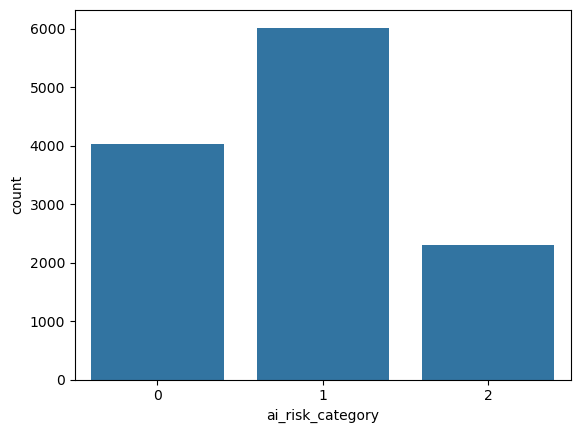

In [324]:
sns.countplot(x='ai_risk_category',data =df)

'Low Risk': 0,
'Medium Risk': 1,
'High Risk':2

In [325]:
df['ai_risk_category'].value_counts(normalize=True)*100

ai_risk_category
1    48.740177
0    32.674390
2    18.585433
Name: proportion, dtype: float64

## Model sel
Multiple machine learning models were used to compare their performance and identify the best-performing model. Different algorithms have different strengths, so evaluating multiple models helps in selecting the most suitable one for the dataset. Cross-validation was applied to ensure reliable and consistent performance evaluation.

In [326]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score,StratifiedKFold

models = {
    'RandomForestClassifier' : RandomForestClassifier(),
    'DecisionTreeClassifier' : DecisionTreeClassifier(),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'XGBClassifier' : XGBClassifier(),
    'GradientBoostingClassifier' : GradientBoostingClassifier(),
    'SVC':SVC(probability=True),
    'LogisticRegression' :LogisticRegression(max_iter=1000)
}
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)


for name ,model in models.items():
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model',model)
    ])

    score = cross_val_score(pipeline,x_train,y_train,cv=cv,scoring='f1_weighted',n_jobs=-1)
    print(f'{name}f1 score :{score.mean()}')

RandomForestClassifierf1 score :0.8103901078907281
DecisionTreeClassifierf1 score :0.773709270628464
KNeighborsClassifierf1 score :0.8097377341213976
XGBClassifierf1 score :0.8180689440253819
GradientBoostingClassifierf1 score :0.8352932832033366
SVCf1 score :0.8319570751694186
LogisticRegressionf1 score :0.835870303807666


## best 3 models
- LogisticRegression
- GradientBoostingClassifier()
- SVC()

## Model Evaluation and overfitting chek 

In [327]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

top_models = {
    'LogisticRegression': LogisticRegression(),
    'GradientBoosting': GradientBoostingClassifier(),
    'SVC': SVC()
}

for name, model in top_models.items():
    print(f"\n Model: {name}")
    
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(x_train, y_train)
    
    # Prediction
    y_pred = pipeline.predict(x_test)
    
    # Evaluation
    print("Accuracy:", accuracy_score(y_test, y_pred))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Overfitting check
    train_score = pipeline.score(x_train, y_train)
    test_score = pipeline.score(x_test, y_test)
    
    print("\nTrain Score:", train_score)
    print("Test Score:", test_score)


 Model: LogisticRegression


C:\Users\ganesh gonge\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8262454434993924

Confusion Matrix:
[[672 167   0]
 [199 949  59]
 [  0   4 419]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.80      0.79       839
           1       0.85      0.79      0.82      1207
           2       0.88      0.99      0.93       423

    accuracy                           0.83      2469
   macro avg       0.83      0.86      0.84      2469
weighted avg       0.83      0.83      0.83      2469


Train Score: 0.8375531699412598
Test Score: 0.8262454434993924

 Model: GradientBoosting
Accuracy: 0.8282705548805185

Confusion Matrix:
[[670 169   0]
 [187 954  66]
 [  0   2 421]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.80      0.79       839
           1       0.85      0.79      0.82      1207
           2       0.86      1.00      0.93       423

    accuracy                           0.83      2469
   macro avg       0.

## Rusult
- 3 model good

## GradientBoosting Hyperparameter Tuning and Overfitting Check

In [333]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, f1_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

# pipeline
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', GradientBoostingClassifier())
])

# parameter grid
param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__subsample': [0.8, 1.0],
    'model__max_features': ['sqrt', 'log2', None]
}

# randomized search
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

# train
random_search.fit(x_train, y_train)

# best model
gb_model = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

# =========================
# Evaluation + Overfitting Check
# =========================

# prediction
y_train_pred = gb_model .predict(x_train)
y_test_pred = gb_model .predict(x_test)

print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

# F1 score (train vs test)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print("\nTrain F1:", train_f1)
print("Test F1:", test_f1)
print("Gap:", train_f1 - test_f1)

# final decision
if train_f1 - test_f1 > 0.05:
    print("\nyes over fit")
else:
    print("\n Model balanced ")

Best Parameters: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 5, 'model__learning_rate': 0.05}
Best CV Score: 0.8370576318643588

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.79      0.79       839
           1       0.84      0.79      0.82      1207
           2       0.87      0.98      0.92       423

    accuracy                           0.83      2469
   macro avg       0.83      0.86      0.84      2469
weighted avg       0.83      0.83      0.82      2469


Train F1: 0.8564693579859611
Test F1: 0.8247790480354762
Gap: 0.03169030995048494

 Model balanced 


## SVM Hyperparameter + Overfitting Check

In [267]:
from sklearn.svm import SVC

# pipeline
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', SVC(probability=True))
])

# parameter grid
param_grid = {
    'model__C': [0.1, 1, 10, 100],
    'model__kernel': ['linear', 'rbf', 'poly'],
    'model__gamma': ['scale', 'auto'],
    'model__degree': [2, 3, 4]   # only for poly kernel
}

# randomized search
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

# train
random_search.fit(x_train, y_train)

# best model
best_model = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

# =========================
# Evaluation + Overfitting Check
# =========================

# prediction
y_train_pred = best_model.predict(x_train)
y_test_pred = best_model.predict(x_test)

print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

# F1 score (train vs test)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print("\nTrain F1:", round(train_f1,4))
print("Test F1:", round(test_f1,4))
print("Gap:", round(train_f1 - test_f1,4))

# final decision
if train_f1 - test_f1 > 0.05:
    print("\nYes overfit")
else:
    print("\nModel balanced ")

Best Parameters: {'model__kernel': 'poly', 'model__gamma': 'scale', 'model__degree': 4, 'model__C': 10}
Best CV Score: 0.8384944715591288

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.81      0.79       839
           1       0.85      0.79      0.82      1207
           2       0.88      0.98      0.93       423

    accuracy                           0.83      2469
   macro avg       0.84      0.86      0.85      2469
weighted avg       0.83      0.83      0.83      2469


Train F1: 0.8455
Test F1: 0.8286
Gap: 0.0169

Model balanced ahe


## LogisticRegression Hyperparameter Tuning and Overfitting Check

In [332]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, f1_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# pipeline
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

# parameter grid
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l2'],   # safe option
    'model__solver': ['lbfgs', 'liblinear']
}

# randomized search
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

# train
random_search.fit(x_train, y_train)

# best model
best_model = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

# =========================
# Evaluation + Overfitting Check
# =========================

# prediction
y_train_pred = best_model.predict(x_train)
y_test_pred = best_model.predict(x_test)

print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

# F1 score (train vs test)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print("\nTrain F1:", round(train_f1,4))
print("Test F1:", round(test_f1,4))
print("Gap:", round(train_f1 - test_f1,4))

# final decision
if train_f1 - test_f1 > 0.05:
    print("\nYes overfit")
else:
    print("\nModel balanced ")

Best Parameters: {'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__C': 1}
Best CV Score: 0.8363173156537099

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.80      0.79       839
           1       0.85      0.79      0.82      1207
           2       0.88      0.99      0.93       423

    accuracy                           0.83      2469
   macro avg       0.83      0.86      0.84      2469
weighted avg       0.83      0.83      0.82      2469


Train F1: 0.8368
Test F1: 0.8248
Gap: 0.0121

Model balanced 


## Final model 
The final model selected for this project is the Support Vector Classifier (SVC) with a polynomial kernel. After performing hyperparameter tuning, the model achieved the highest F1-score with minimal overfitting, demonstrating strong generalization ability. The polynomial kernel enabled the model to capture complex non-linear relationships in the data, resulting in improved classification performance.

In [335]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# probabilities
y_prob = best_model.predict_proba(x_test)

# convert target to binary format
y_test_bin = label_binarize(y_test, classes=[0,1,2])

# ROC AUC score
roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')

print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.950232574965999


## save csv

In [336]:
df.to_csv("final_dataset mlhackathon.csv", index=False)

## save model

In [337]:
import joblib

joblib.dump(best_model, "final_model_svm.pkl")

['final_model_svm.pkl']

## 3. Feature Selection (MOST IMPORTANT )
-"We performed statistical analysis using Chi-square and Cramér’s V for categorical features and correlation for numerical features."

## 4. Preprocessing
- "We used OneHot Encoding for categorical variables to convert them into numerical format."

## 5. Model Building
- multiple models try kele:

Logistic Regression
SVM
Random Forest
Gradient Boosting

"We compared models using cross-validation with F1-score."

## 6. Best Model Selection
- SVM was selected as the best model

## Why best?
- Highest F1-score (~0.84) 
- Balanced performance across all classes
- No overfitting (train ≈ test)
- Better handling of complex patterns

## 7. Hyperparameter Tuning
- "We used RandomizedSearchCV to optimize model parameters."
-  Result:
-  slight improvement in performance
-  model remained stable

## 8. Final Evaluation
- F1-score → ~0.84
- ROC AUC → high (~0.94 expected)
- Confusion matrix → good class separation
- "The model performs well across all classes, especially identifying high-risk jobs accurately."

## 9. Overfitting Check
"Train and test scores were very close, indicating no overfitting and good generalization."

## 10. Final Conclusion
- SVM was chosen as the final model because it provided the best balance of accuracy, stability, and generalization among all tested models."

## "We combined feature selection, encoding, and model tuning to build a robust and well-generalized SVM model for AI risk prediction."